In [46]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [47]:
# data = pd.read_csv('proyecto-1-inteligencia-artificial/data/crop_recommendation.csv')
data = pd.read_csv('../data/crop_recommendation.csv')
data.head()

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


In [48]:
# Definicion de variables
X = data.drop(columns=['label'])
y = data.label
X.shape, y.shape

((2200, 7), (2200,))

### 1: Decision Tree

In [49]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from sklearn.model_selection import train_test_split

In [50]:
# Separación de los conjuntos
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [51]:
dt_model = DecisionTreeClassifier(max_depth= 50, random_state=42) # Por defecto, trabaja con gini como criterio
dt_model.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,50
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [52]:
# Desempeño
from sklearn.metrics import classification_report, confusion_matrix

In [53]:
# Resultados
y_pred = dt_model.predict(X_test)
print(confusion_matrix(y_test, y_pred))

[[23  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0 21  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0 20  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0 26  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0 27  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0 17  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0 17  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0 14  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0 22  0  0  0  0  0  0  0  0  0  0  0  1  0]
 [ 0  0  0  0  0  0  0  0  0 20  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0 11  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  1  0  0  0  0  0  0 20  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0  0  0 19  0  0  0  0  0  0  0  0  0]
 [ 0  0  1  0  0  0  0  0  0  0  1  0  0 22  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0  0

In [54]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        23
      banana       1.00      1.00      1.00        21
   blackgram       0.95      1.00      0.98        20
    chickpea       1.00      1.00      1.00        26
     coconut       0.96      1.00      0.98        27
      coffee       1.00      1.00      1.00        17
      cotton       1.00      1.00      1.00        17
      grapes       1.00      1.00      1.00        14
        jute       0.92      0.96      0.94        23
 kidneybeans       1.00      1.00      1.00        20
      lentil       0.92      1.00      0.96        11
       maize       1.00      0.95      0.98        21
       mango       1.00      1.00      1.00        19
   mothbeans       1.00      0.92      0.96        24
    mungbean       1.00      1.00      1.00        19
   muskmelon       1.00      1.00      1.00        17
      orange       1.00      1.00      1.00        14
      papaya       1.00    

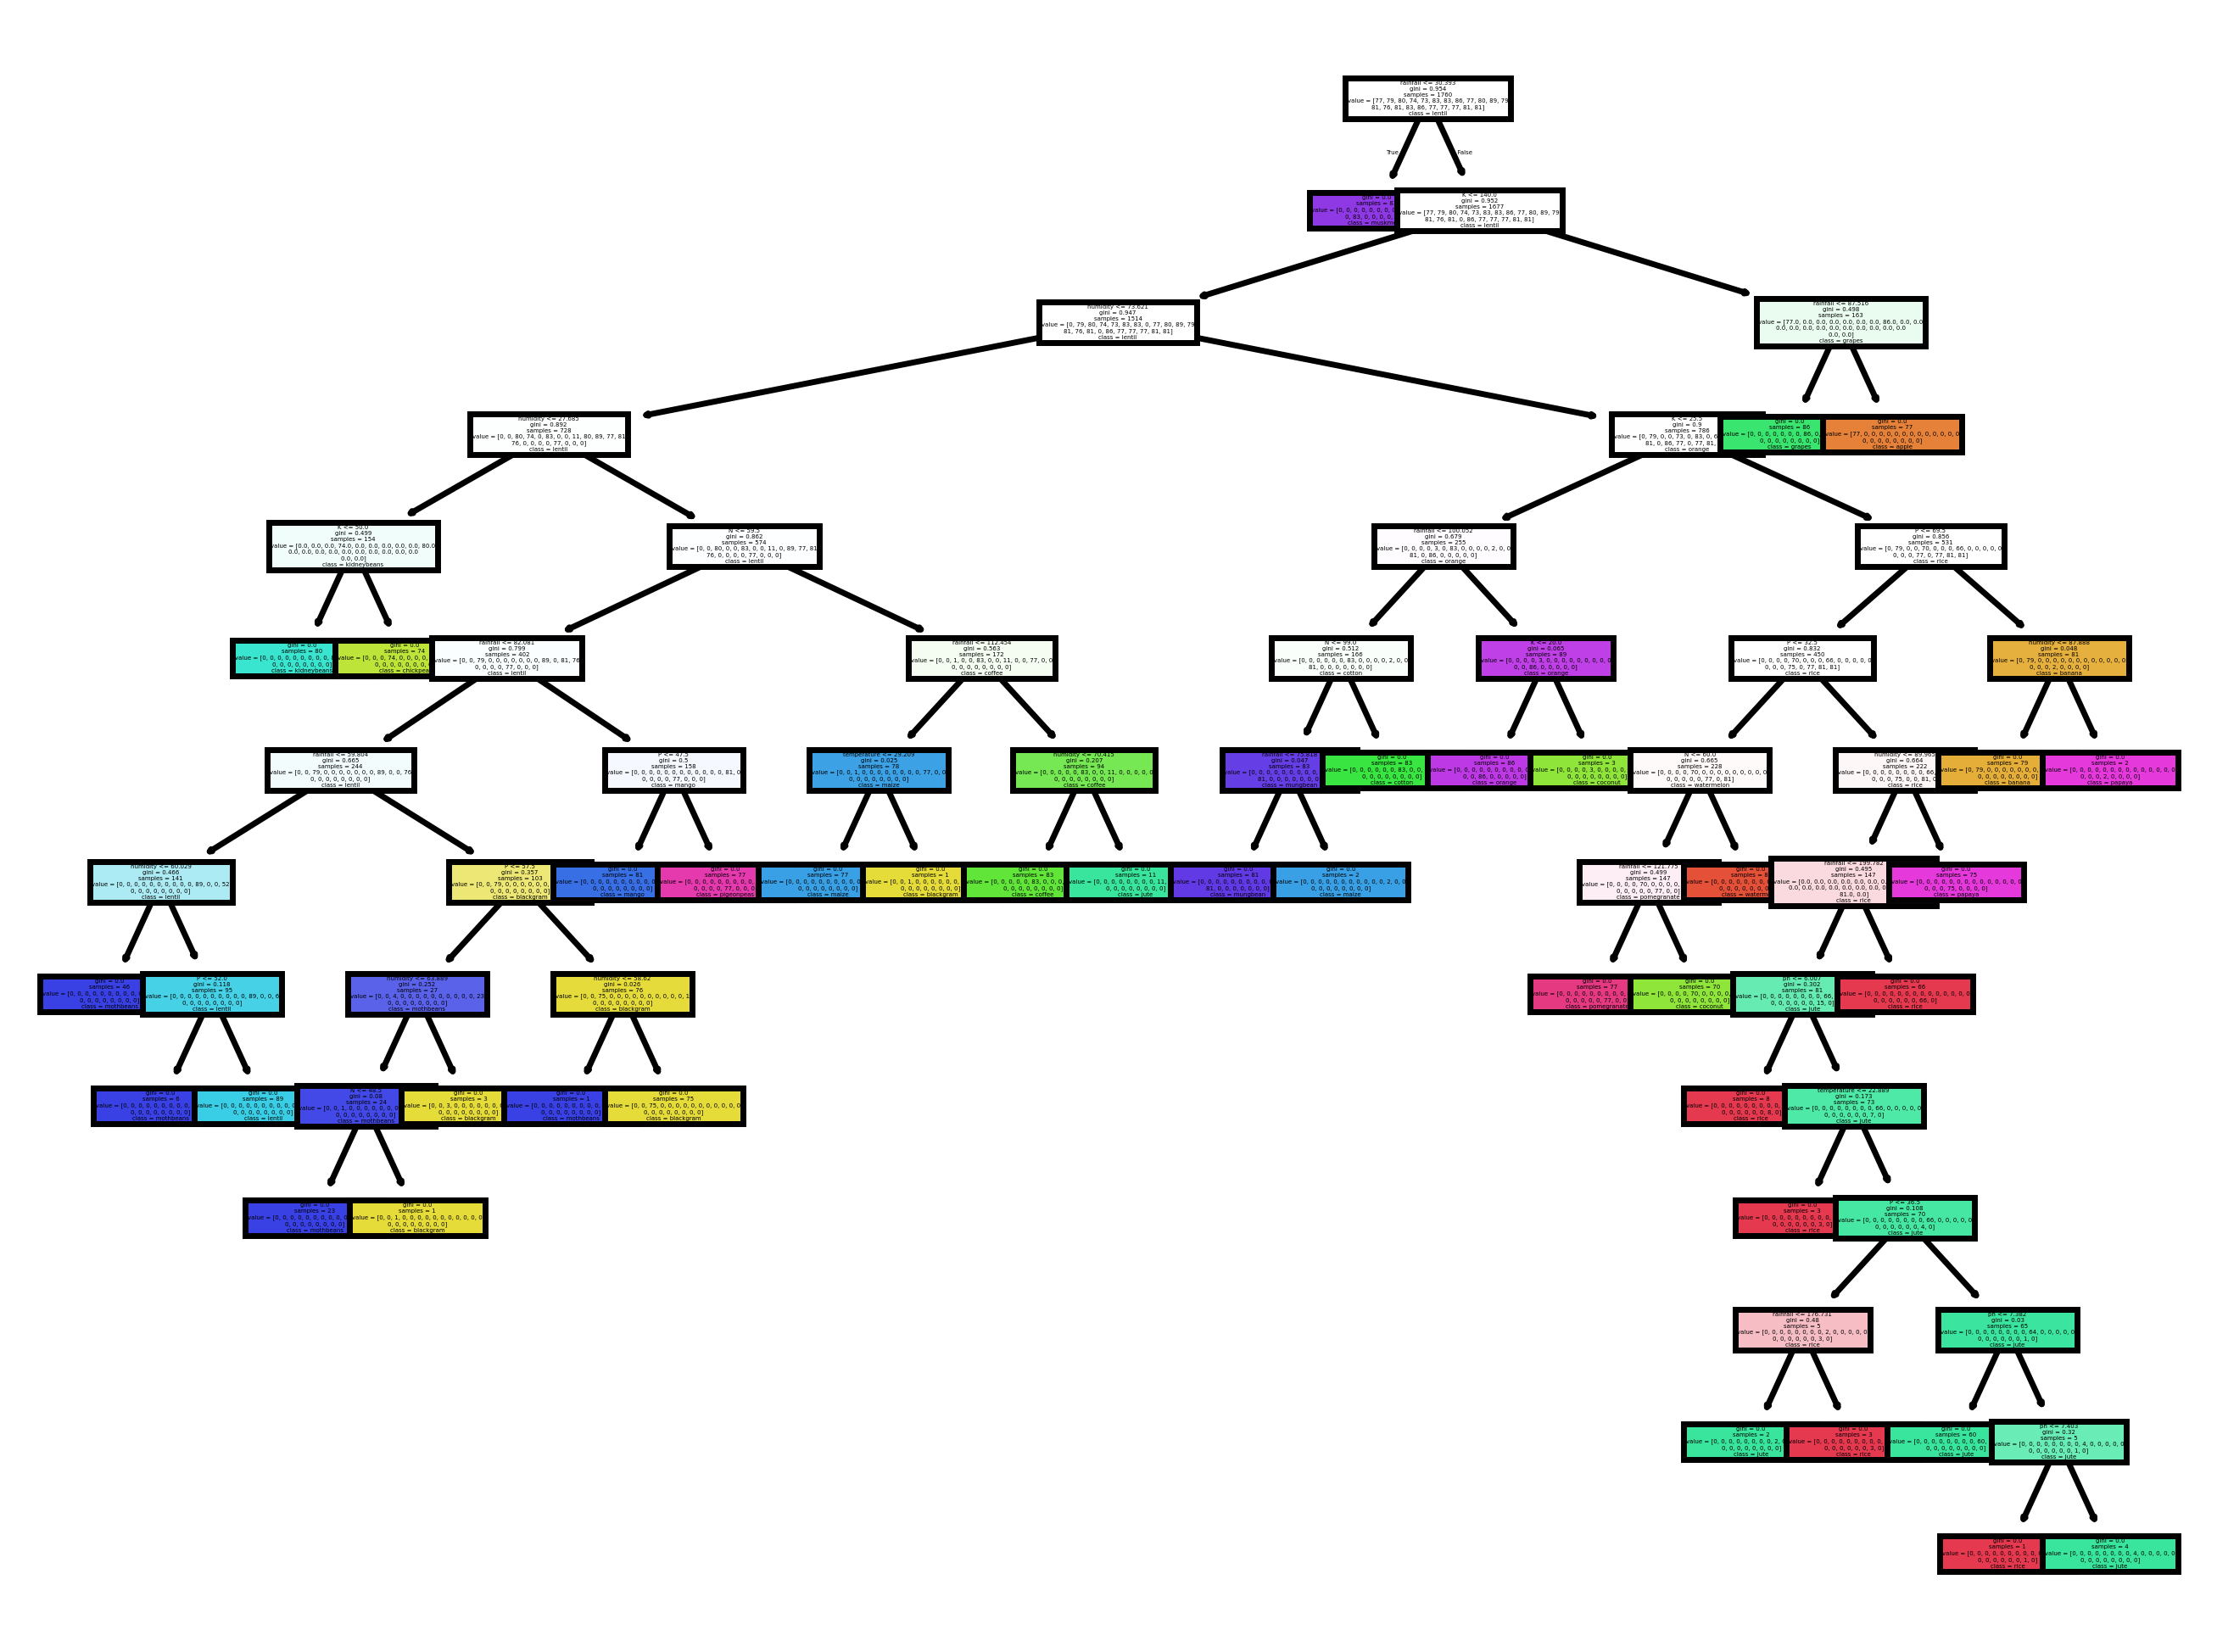

In [55]:
plt.figure(dpi=500)
plot_tree(dt_model, filled = True, feature_names= dt_model.feature_names_in_, class_names = dt_model.classes_)
plt.show()

In [56]:
# Score obtenido
dt_model.score(X_test, y_test)

0.9863636363636363

##### Pesos de columnas

In [57]:
# Peso de cada atributo
pd.DataFrame(dt_model.feature_importances_, index = X.columns)

,0
N,0.141650
P,0.162547
K,0.145078
temperature,0.004220
humidity,0.187216
ph,0.008189
rainfall,0.351099


El atributo con mayor peso es 'rainfall'.

#### GridSearchCV

Hagamos pruebas para trabajar con los mejores estimadores.

In [58]:
from sklearn.model_selection import GridSearchCV

In [59]:
params = {
    'criterion' : ['gini', 'entropy', 'log_loss'],
    'max_depth' : [None, 15, 30, 50, 100],
    'splitter' : ['best', 'random']
}
grid_s = GridSearchCV(DecisionTreeClassifier(random_state=42), params, n_jobs=12, verbose=1, scoring='roc_auc_ovr')
grid_s.fit(X_train, y_train)

Fitting 5 folds for each of 30 candidates, totalling 150 fits


,estimator,DecisionTreeC...ndom_state=42)
,param_grid,"{'criterion': ['gini', 'entropy', ...], 'max_depth': [None, 15, ...], 'splitter': ['best', 'random']}"
,scoring,'roc_auc_ovr'
,n_jobs,12
,refit,True
,cv,None
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'gini'


In [80]:
display(grid_s.best_params_)
display(grid_s.best_score_)
display(grid_s.best_estimator_.get_depth())

{'criterion': 'gini', 'max_depth': None, 'splitter': 'best'}

np.float64(0.9922030579320212)

13

In [61]:
# Validacion cruzada
from sklearn.model_selection import cross_val_score

In [62]:
cv = cross_val_score(grid_s, X_train, y_train, scoring='accuracy', cv=5)

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Fitting 5 folds for each of 30 candidates, totalling 150 fits
Fitting 5 folds for each of 30 candidates, totalling 150 fits
Fitting 5 folds for each of 30 candidates, totalling 150 fits
Fitting 5 folds for each of 30 candidates, totalling 150 fits


In [63]:
print(cv.mean(), cv.std())

0.9852272727272726 0.006327004957761406


### 2: Random Forest

In [64]:
from sklearn.ensemble import RandomForestClassifier

In [65]:
# Crear y entrenar clasificador
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [66]:
# Score que alcanza el modelo
y_pred = rf_model.predict(X_test)
rf_model.score(X_test, y_test)

0.9931818181818182

In [67]:
# Resultados
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        23
      banana       1.00      1.00      1.00        21
   blackgram       1.00      1.00      1.00        20
    chickpea       1.00      1.00      1.00        26
     coconut       1.00      1.00      1.00        27
      coffee       1.00      1.00      1.00        17
      cotton       1.00      1.00      1.00        17
      grapes       1.00      1.00      1.00        14
        jute       0.92      1.00      0.96        23
 kidneybeans       1.00      1.00      1.00        20
      lentil       0.92      1.00      0.96        11
       maize       1.00      1.00      1.00        21
       mango       1.00      1.00      1.00        19
   mothbeans       1.00      0.96      0.98        24
    mungbean       1.00      1.00      1.00        19
   muskmelon       1.00      1.00      1.00        17
      orange       1.00      1.00      1.00        14
      papaya       1.00    

In [68]:
# Peso de cada columna al Random Forest
pd.DataFrame(rf_model.feature_importances_, index = X.columns)

,0
N,0.108859
P,0.143622
K,0.181222
temperature,0.075682
humidity,0.211279
ph,0.052301
rainfall,0.227036


El mayor peso lo sigue poseyendo 'rainfall' seguido de 'humidity', más no alcanzan números tan altos como en el caso del [Decision Tree](#pesos-de-columnas).

#### GridSearchCV

In [69]:
params = {
    'criterion' : ['gini', 'entropy', 'log_loss'],
    'max_depth' : [None, 15, 30, 50, 100],
}
grid_rf = GridSearchCV(RandomForestClassifier(random_state=42), params, n_jobs=12, verbose=1, scoring='accuracy')
grid_rf.fit(X_train, y_train)

Fitting 5 folds for each of 15 candidates, totalling 75 fits


,estimator,RandomForestC...ndom_state=42)
,param_grid,"{'criterion': ['gini', 'entropy', ...], 'max_depth': [None, 15, ...]}"
,scoring,'accuracy'
,n_jobs,12
,refit,True
,cv,None
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,100


In [70]:
display(grid_rf.best_params_)
display(grid_rf.best_score_)

{'criterion': 'gini', 'max_depth': 15}

np.float64(0.9954545454545455)

In [71]:
cv_rf = cross_val_score(grid_rf, X_train, y_train, scoring='accuracy', cv=5)

Fitting 5 folds for each of 15 candidates, totalling 75 fits
Fitting 5 folds for each of 15 candidates, totalling 75 fits
Fitting 5 folds for each of 15 candidates, totalling 75 fits
Fitting 5 folds for each of 15 candidates, totalling 75 fits
Fitting 5 folds for each of 15 candidates, totalling 75 fits


In [72]:
print(cv_rf.mean(), cv_rf.std())

0.9943181818181819 0.005959141182784973


Se observan mejores resultados que en el Decision Tree.

In [73]:
pd.DataFrame(grid_rf.best_estimator_.feature_importances_, index = X.columns)

,0
N,0.108650
P,0.142226
K,0.181841
temperature,0.073635
humidity,0.213023
ph,0.052725
rainfall,0.227900


### 3: Curva ROC AUC

Por motivos de que son 22 cosechas distintas posibles, se probará comparar el desempeño con respecto a la clase 'rice'

In [74]:
from sklearn.metrics import roc_curve, roc_auc_score, auc

Con el GridSearch, se obtienen pesos bastante similares al caso normal.

In [75]:
rice_bin = (y_test == "rice").astype(int)
dt_rice_idx = list(grid_s.classes_).index("rice") # Para Tomar las entradas específicas (Decision Tree)
dt_score = grid_s.predict_proba(X_test)[:, dt_rice_idx]

rf_rice_idx = list(grid_rf.classes_).index("rice") # Para Tomar las entradas específicas (Random Forest)
rf_score = grid_rf.predict_proba(X_test)[:, dt_rice_idx]

In [76]:
# True Y False Positive Rate
dt_fpr, dt_tpr, _ = roc_curve(rice_bin, dt_score)
auc_dt = auc(dt_fpr, dt_tpr)

rf_fpr, rf_tpr, _ = roc_curve(rice_bin, rf_score)
auc_rf = auc(rf_fpr, rf_tpr)

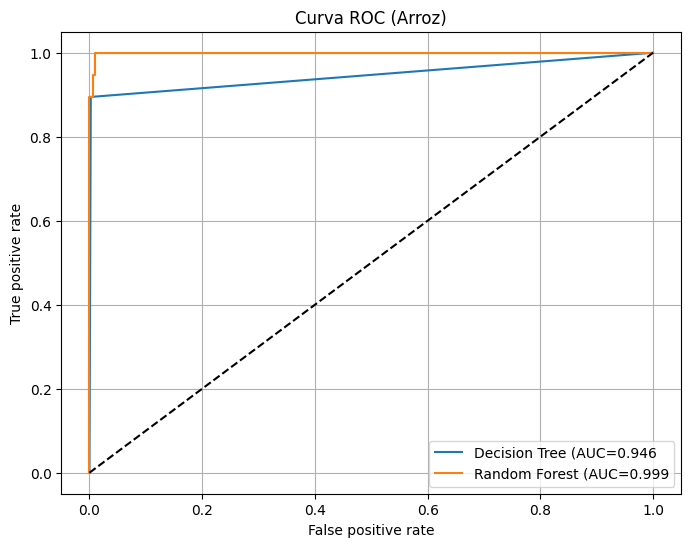

In [77]:
plt.figure(figsize=(8,6))

plt.plot(dt_fpr, dt_tpr,
         label=f'Decision Tree (AUC={auc_dt:.3f}')

plt.plot(rf_fpr, rf_tpr,
         label=f'Random Forest (AUC={auc_rf:.3f}')

plt.plot([0,1], [0,1], 'k--')

plt.xlabel('False positive rate')
plt.ylabel('True positive rate')
plt.title('Curva ROC (Arroz)')
plt.legend()
plt.grid(True)

plt.show()

In [78]:
# Área bajo cada curva
print('Área bajo la curva del Decision Tree:', auc_dt)
print('Área bajo la curva del Random Forest:', auc_rf)

Área bajo la curva del Decision Tree: 0.9461807725965746
Área bajo la curva del Random Forest: 0.9991248906113265


Observando así un mejor desempeño con el Random Forest, pudiendo llegar al concenso de que los mm de agua de las precipitaciones, en conjunto al porcentaje de humedad, son los que aportan más a la clasificación.

Resumen:
| Estimador | GridSearchCV : Score | Criterio | Profundidad | CV : Mean | CV : StandardDeviation |
| --------- | ----- | ---------------- | --- | --- | --- |
| **Decision Tree** | 0.9927764087062908 | Gini | 13 | 0.9852272727272726 | 0.006327004957761406 |
| **Random Forest** | 0.9954545454545455 | Gini | 15 | 0.9943181818181819 | 0.005959141182784973 |